In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              average_precision_score, precision_recall_curve, roc_curve)

DATA = "../data"

flat = pd.read_parquet(f"{DATA}/features_flat_event.parquet")
spatial = pd.read_parquet(f"{DATA}/features_spatial_event.parquet")
labels = pd.read_parquet(f"{DATA}/labels_q2_shot_in_n.parquet")
splits = pd.read_parquet(f"{DATA}/splits.parquet")

torch.manual_seed(42)
np.random.seed(42)

In [2]:
df = flat.merge(labels[['match_id', 'event_uuid', 'label']], on=['match_id', 'event_uuid'])
df = df.merge(splits, on='match_id')

# Restrict to events where 360 features exist (so eligibility matches the other Q2 models)
events_with_360 = spatial.dropna(subset=['teammates_within_10m'])[['match_id', 'event_uuid']]
before = len(df)
df = df.merge(events_with_360, on=['match_id', 'event_uuid'])
print(f"After 360 restriction: {before:,} -> {len(df):,}")
print(f"Positive rate: {df['label'].mean():.4f}")

After 360 restriction: 86,079 -> 26,341
Positive rate: 0.0408


In [3]:
NUMERIC_COLS = ['ball_x', 'ball_y', 'dist_to_goal', 'angle_to_goal',
                'is_pass', 'is_carry', 'is_dribble', 'is_shot']
CATEGORICAL_COLS = ['zone']

train = df[df['split'] == 'train']
val = df[df['split'] == 'val']
test = df[df['split'] == 'test']

prep = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS),
])

X_train = torch.FloatTensor(prep.fit_transform(train).astype(np.float32))
X_val = torch.FloatTensor(prep.transform(val).astype(np.float32))
X_test = torch.FloatTensor(prep.transform(test).astype(np.float32))
y_train = torch.FloatTensor(train['label'].values)
y_val = torch.FloatTensor(val['label'].values)
y_test = torch.FloatTensor(test['label'].values)

n_neg = (y_train == 0).sum().item()
n_pos = (y_train == 1).sum().item()
pos_weight = torch.tensor([n_neg / n_pos])
print(f"pos_weight = {pos_weight.item():.2f}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

pos_weight = 24.51
Train: torch.Size([18619, 14]), Val: torch.Size([3469, 14]), Test: torch.Size([4253, 14])


In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),     nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP(in_dim=X_train.shape[1])
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_val_pr = 0
best_state = None
patience = 15
since_improve = 0
history = []

batch_size = 512
n = X_train.shape[0]

for epoch in range(200):
    model.train()
    perm = torch.randperm(n)
    total_loss = 0
    for i in range(0, n, batch_size):
        idx = perm[i:i+batch_size]
        optimizer.zero_grad()
        logits = model(X_train[idx])
        loss = loss_fn(logits, y_train[idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)

    model.eval()
    with torch.no_grad():
        val_proba = torch.sigmoid(model(X_val)).numpy()
    val_pr = average_precision_score(y_val.numpy(), val_proba)
    history.append(val_pr)

    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        since_improve = 0
    else:
        since_improve += 1

    print(f"Epoch {epoch:3d}: train loss={total_loss/n:.4f}, val PR-AUC={val_pr:.4f}")

    if since_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nBest val PR-AUC: {best_val_pr:.4f}")

Epoch   0: train loss=1.2796, val PR-AUC=0.1048
Epoch   1: train loss=1.1843, val PR-AUC=0.1201
Epoch   2: train loss=1.1704, val PR-AUC=0.1215
Epoch   3: train loss=1.1507, val PR-AUC=0.1269
Epoch   4: train loss=1.1573, val PR-AUC=0.1235
Epoch   5: train loss=1.1625, val PR-AUC=0.1300
Epoch   6: train loss=1.1551, val PR-AUC=0.1312
Epoch   7: train loss=1.1570, val PR-AUC=0.1255
Epoch   8: train loss=1.1485, val PR-AUC=0.1304
Epoch   9: train loss=1.1484, val PR-AUC=0.1274
Epoch  10: train loss=1.1508, val PR-AUC=0.1237
Epoch  11: train loss=1.1551, val PR-AUC=0.1282
Epoch  12: train loss=1.1515, val PR-AUC=0.1251
Epoch  13: train loss=1.1511, val PR-AUC=0.1277
Epoch  14: train loss=1.1503, val PR-AUC=0.1250
Epoch  15: train loss=1.1405, val PR-AUC=0.1266
Epoch  16: train loss=1.1455, val PR-AUC=0.1295
Epoch  17: train loss=1.1514, val PR-AUC=0.1238
Epoch  18: train loss=1.1453, val PR-AUC=0.1279
Epoch  19: train loss=1.1494, val PR-AUC=0.1269
Epoch  20: train loss=1.1484, val PR-AUC

In [6]:
model.eval()
with torch.no_grad():
    y_proba = torch.sigmoid(model(X_test)).numpy()
y_pred = (y_proba >= 0.5).astype(int)
y_test_np = y_test.numpy()

print(f"Test accuracy: {accuracy_score(y_test_np, y_pred):.4f}")
print(f"Test F1:       {f1_score(y_test_np, y_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test_np, y_proba):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test_np, y_proba):.4f}")

Test accuracy: 0.7153
Test F1:       0.2080
Test ROC-AUC:  0.7952
Test PR-AUC:   0.2387


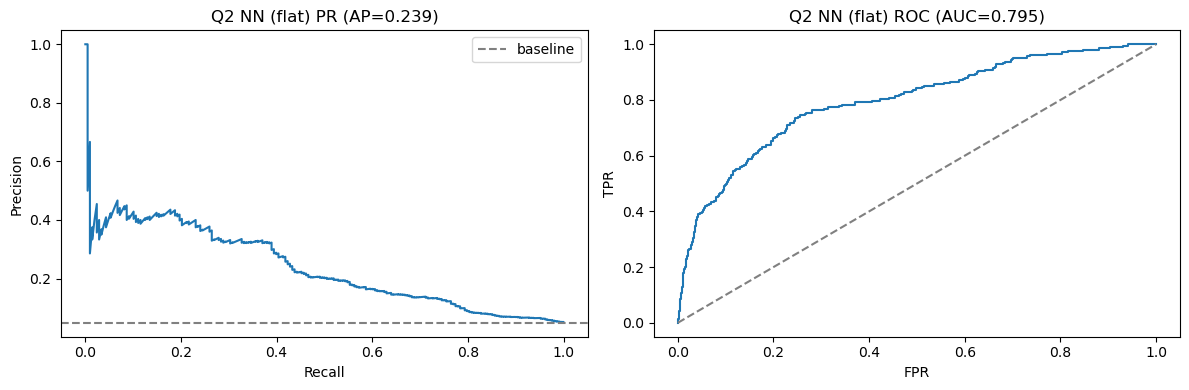

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

prec, rec, _ = precision_recall_curve(y_test_np, y_proba)
axes[0].plot(rec, prec)
axes[0].axhline(y_test_np.mean(), linestyle='--', color='gray', label='baseline')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Q2 NN (flat) PR (AP={average_precision_score(y_test_np, y_proba):.3f})')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test_np, y_proba)
axes[1].plot(fpr, tpr)
axes[1].plot([0,1], [0,1], linestyle='--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'Q2 NN (flat) ROC (AUC={roc_auc_score(y_test_np, y_proba):.3f})')

plt.tight_layout()
plt.show()